### 1. Import Library yang dibutuhkan

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

### 2. Fungsi untuk membaca file citra

In [3]:
def get_xray_image():
    # Pastikan nama file ini sama dengan yang anda apload ke colab
    filename = 'x-ray.jpg'

    # Cek apakah file ada di direktori colab
    if os.path.exists(filename):
        print(f"Berhasil membaca gambar lokal: {filename}")
        # Membaca gambar dalam format grayscale
        img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
        return img
    else:
        # Plan B: Jika file belum di-upload/salah nama, buat gambar X-ray buatan
        print(f"Peringatan: File '{filename}' tidak ditemukan. Membuat gambar X-ray buatan.")
        print("Pastikan Anda sudah mengupload gambar ke panel kiri (Files).")
        print("Menggunakan X-Ray Sintetis untuk melanjutkan demo sementara...\n")

        # Membuat background hitam (jaringan lunak)
        img = np.zeros((500, 500), dtype=np.uint8)
        # Membuat gambar "Tulang" (warna abu-abu terang)
        cv2.ellipse(img, (250, 250), (60, 200), 0, 0, 360, 200, -1)
        img = cv2.GaussianBlur(img, (21, 21), 0) # Efek soft X-Ray
        # Menambahkan "Hairline Fracture" (Patahan rambut hitam tebal 1-2 pixel)
        cv2.line(img, (180, 250), (320, 260), (50, 50, 50), 2)
        return img

### 3. Membaca Citra Lokal (Skenario Kasus)

In [5]:
# memanggil fungsi
img_original = get_xray_image()

Berhasil membaca gambar lokal: x-ray.jpg


### 4. Simulasi Masalah 1: UNDERSAMPLING (Resolusi Spasial Rendah)

In [6]:
# Kita perkecil gambar menjadi 10% dari ukuran aslinya
scale_factor = 0.1
width = int(img_original.shape[1] * scale_factor)
height = int(img_original.shape[0] * scale_factor)

# Proses pemotongan matriks (Downsampling)
img_small = cv2.resize(img_original, (width, height), interpolation=cv2.INTER_NEAREST)

# Kita besarkan kembali ke ukuran asli untuk ditampilkan ke layar dokter
# Menggunakan INTER_NEAREST agar efek "kotak-kotak" pixelnya terlihat jelas
img_downsampled = cv2.resize(img_small, (img_original.shape[1], img_original.shape[0]), interpolation=cv2.INTER_NEAREST)

### 5. SIMULASI MASALAH 2: LOW QUANTIZATION (Bit Depth Rendah)

In [7]:
# Aslinya gambar adalah 8-bit (256 tingkat warna abu-abu: 0-255)
# Kita akan simulasikan mesin klinik yang buruk, hanya merekam 3-bit (8 tingkat warna)
bit_depth = 3
levels = 2 ** bit_depth # 2^3 = 8 level

# Rumus Kuantisasi: Membagi rentang 256 menjadi 8 blok/tangga
img_quantized = np.floor((img_original / 256.0) * levels) * (256.0 / levels)
img_quantized = img_quantized.astype(np.uint8)

### 6. Simulasi keduanya (Undersampling & Low Quantization)

In [8]:
# Quantisized downsampled img
img_downsampled_quantisized = np.floor((img_downsampled / 256.0) * levels) * (256.0 / levels)
img_downsampled_quantisized = img_downsampled_quantisized.astype(np.uint8)

### 7. VISUALISASI HASIL DENGAN MATPLOTLIB

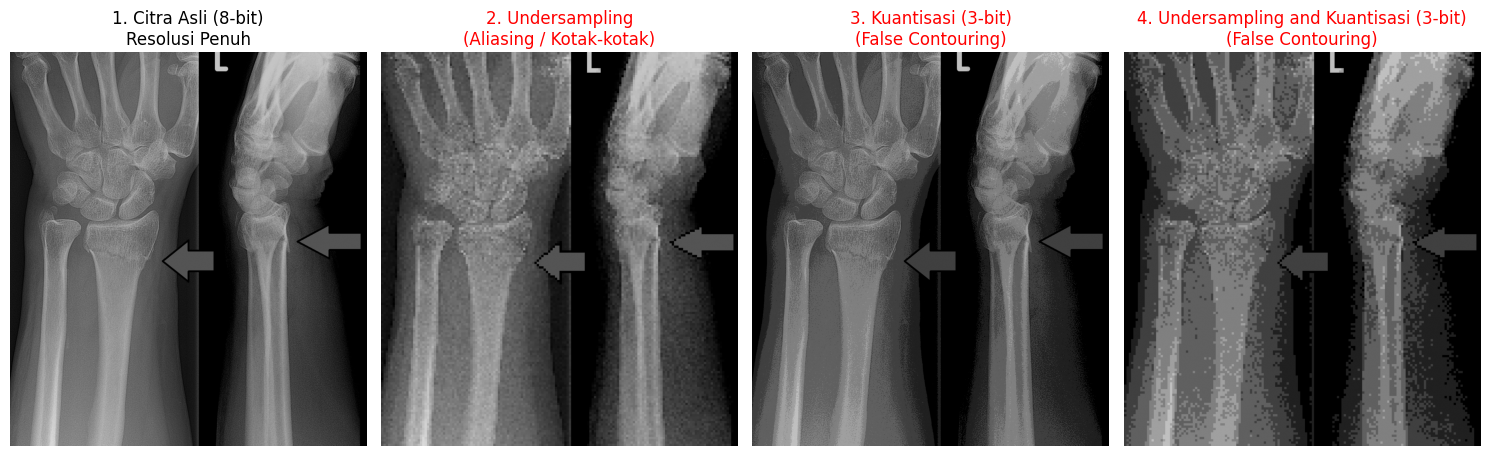

In [9]:
plt.figure(figsize=(15, 6))

# Plot 1: Citra Asli
plt.subplot(1, 4, 1)
plt.title("1. Citra Asli (8-bit)\nResolusi Penuh", fontsize=12)
plt.imshow(img_original, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

# Plot 2: Hasil Undersampling
plt.subplot(1, 4, 2)
plt.title("2. Undersampling\n(Aliasing / Kotak-kotak)", fontsize=12, color='red')
plt.imshow(img_downsampled, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

# Plot 3: Hasil Kuantisasi Rendah
plt.subplot(1, 4, 3)
plt.title(f"3. Kuantisasi ({bit_depth}-bit)\n(False Contouring)", fontsize=12, color='red')
plt.imshow(img_quantized, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

# Plot 3: Hasil Undersampling dan Kuantisasi Rendah
plt.subplot(1, 4, 4)
plt.title(f"4. Undersampling and Kuantisasi ({bit_depth}-bit)\n(False Contouring)", fontsize=12, color='red')
plt.imshow(img_downsampled_quantisized, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()